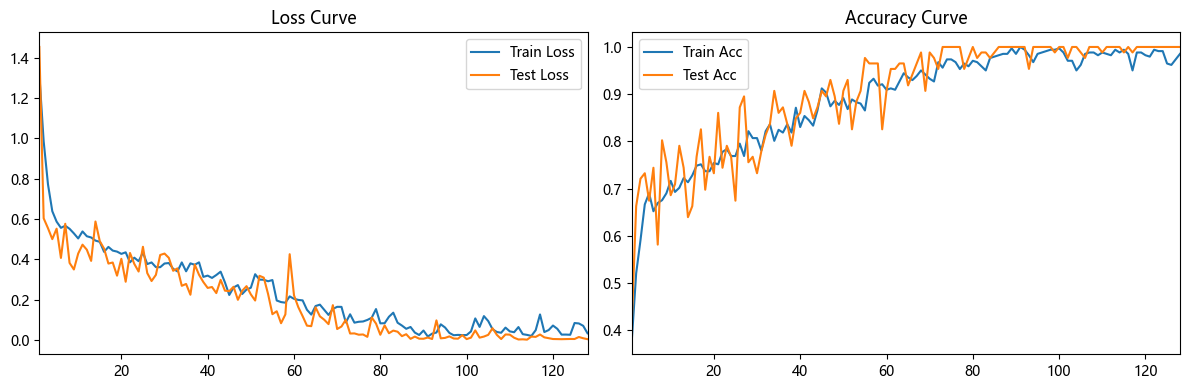

Epoch 128/128 │ Train Loss: 0.0328, Train Acc: 98.54% │ Test Loss: 0.0036, Test Acc: 100.00%


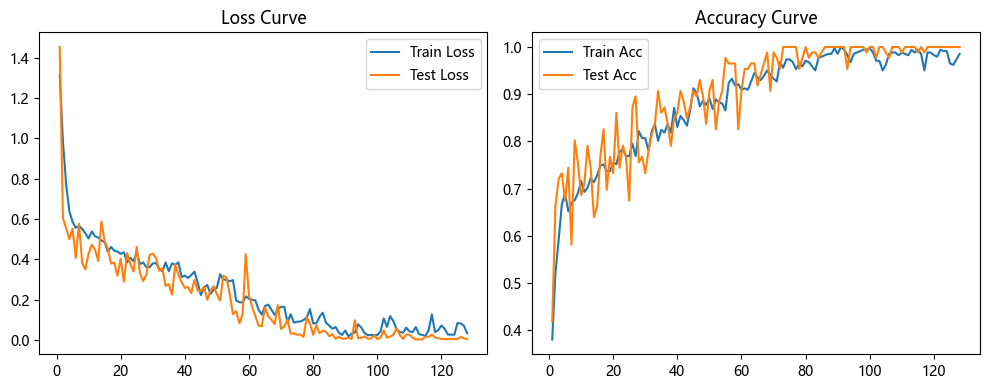

Top-2 models:
  Acc=1.0000 → C:\Users\nihao\Desktop\Database\吞咽病患四分类\best_models\epoch073_acc1.0000.pth
  Acc=1.0000 → C:\Users\nihao\Desktop\Database\吞咽病患四分类\best_models\epoch074_acc1.0000.pth


In [4]:
import os
import librosa
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import sys

# -----------------------
# 全局配置
# -----------------------
dataset_path = r"C:\Users\nihao\Desktop\Database\吞咽病患四分类\吞咽"
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SAMPLE_RATE   = 32000
N_MFCC        = 40
N_FFT         = 1024
HOP_LENGTH    = 512
BATCH_SIZE    = 16
LEARNING_RATE = 0.001
EPOCHS        = 128

# 固定音频时长
FIXED_DURATION = 2.0  
FIXED_LENGTH   = int(SAMPLE_RATE * FIXED_DURATION)  


# -------------------------------------------------------
# 1. 加载音频文件路径和标签
# -------------------------------------------------------
def load_audio_files(dataset_path):
    file_paths, labels = [], []
    for label in os.listdir(dataset_path):
        subfolder = os.path.join(dataset_path, label)
        if os.path.isdir(subfolder):
            for file in os.listdir(subfolder):
                if file.endswith('.wav'):
                    file_paths.append(os.path.join(subfolder, file))
                    labels.append(label)
    return file_paths, labels


# -------------------------------------------------------
# 2. MFCC Dataset（ delta & delta-delta）
# -------------------------------------------------------
class MFCCDataset(Dataset):
    def __init__(self, file_paths, labels,
                 sr=SAMPLE_RATE, n_mfcc=N_MFCC,
                 n_fft=N_FFT, hop_length=HOP_LENGTH,
                 fixed_length=FIXED_LENGTH):
        self.file_paths   = file_paths
        self.labels       = labels
        self.sr           = sr
        self.n_mfcc       = n_mfcc
        self.n_fft        = n_fft
        self.hop_length   = hop_length
        self.fixed_length = fixed_length

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label     = self.labels[idx]

        # 1) 加载音频
        y, _ = librosa.load(file_path, sr=self.sr)

        # 2) 截断/补零到固定长度
        if len(y) > self.fixed_length:
            y = y[:self.fixed_length]
        else:
            y = np.pad(y, (0, self.fixed_length - len(y)), 'constant')

        # 3) 计算 MFCC
        mfcc        = librosa.feature.mfcc(y=y, sr=self.sr,
                                           n_mfcc=self.n_mfcc,
                                           n_fft=self.n_fft,
                                           hop_length=self.hop_length)
        mfcc_delta  = librosa.feature.delta(mfcc)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

        # 4) 多通道堆叠
        features = np.stack([mfcc, mfcc_delta, mfcc_delta2], axis=0)
        return torch.tensor(features, dtype=torch.float32), torch.tensor(label, dtype=torch.long)


# -------------------------------------------------------
# 3. 定义残差块 (Residual Block)
# -------------------------------------------------------
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1,
                 downsample=None, dropout=0.0):
        super().__init__()
        self.conv1      = nn.Conv2d(in_channels, out_channels,
                                    kernel_size=3, stride=stride,
                                    padding=1, bias=False)
        self.bn1        = nn.BatchNorm2d(out_channels)
        self.relu       = nn.ReLU(inplace=True)
        self.conv2      = nn.Conv2d(out_channels, out_channels,
                                    kernel_size=3, stride=1,
                                    padding=1, bias=False)
        self.bn2        = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        self.dropout    = nn.Dropout2d(dropout)

    def forward(self, x):
        identity = x
        out      = self.conv1(x)
        out      = self.bn1(out)
        out      = self.relu(out)
        out      = self.dropout(out)
        out      = self.conv2(out)
        out      = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)


# -------------------------------------------------------
# 4. ResNet-like网络
# -------------------------------------------------------
class ResNetLike(nn.Module):
    def __init__(self, num_classes=10, dropout=0.2):
        super().__init__()
        # stem
        self.conv1   = nn.Conv2d(3, 32, kernel_size=7, stride=2,
                                 padding=3, bias=False)
        self.bn1     = nn.BatchNorm2d(32)
        self.relu    = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        # layers
        self.layer1  = self._make_layer(32, 32, blocks=2, stride=1, dropout=dropout)
        self.layer2  = self._make_layer(32, 64, blocks=2, stride=2, dropout=dropout)
        self.layer3  = self._make_layer(64, 128, blocks=2, stride=2, dropout=dropout)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc          = nn.Linear(128, num_classes)

    def _make_layer(self, in_c, out_c, blocks, stride=1, dropout=0.0):
        downsample = None
        if stride != 1 or in_c != out_c:
            downsample = nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_c),
            )
        layers = [ResidualBlock(in_c, out_c, stride, downsample, dropout)]
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_c, out_c, 1, None, dropout))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x);    x = self.bn1(x);    x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x);   x = self.layer2(x); x = self.layer3(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


# -------------------------------------------------------
# 5. 训练
# -------------------------------------------------------
def main():
    # 准备存模型的目录
    best_model_dir = os.path.join(os.path.dirname(dataset_path), 'best_models')
    os.makedirs(best_model_dir, exist_ok=True)

    # 加载数据路径与标签
    file_paths, labels = load_audio_files(dataset_path)
    le                 = LabelEncoder()
    encoded_labels     = le.fit_transform(labels)
    num_classes        = len(le.classes_)

    # 初始化模型、损失、优化器
    model     = ResNetLike(num_classes=num_classes, dropout=0.3).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 记录曲线
    train_losses, test_losses = [], []
    train_accs,   test_accs   = [], []

    # Top-2 最佳模型列表
    best_models = []  # 元组 (test_acc, path)

    for epoch in range(1, EPOCHS + 1):
        clear_output(wait=True)

        # 划分
        tp, vp, tl, vl = train_test_split(
            file_paths, encoded_labels, test_size=0.2, random_state=epoch
        )
        train_ds = MFCCDataset(tp, tl)
        test_ds  = MFCCDataset(vp, vl)
        train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        test_ld  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

        # 训练
        model.train()
        sum_loss = corr = tot = 0
        for X, y in train_ld:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out  = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            sum_loss += loss.item() * y.size(0)
            preds    = out.argmax(1)
            corr    += (preds == y).sum().item()
            tot     += y.size(0)

        train_loss = sum_loss / tot
        train_acc  = corr / tot
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # 测试
        model.eval()
        sum_loss = corr = tot = 0
        with torch.no_grad():
            for X, y in test_ld:
                X, y     = X.to(device), y.to(device)
                out      = model(X)
                loss     = criterion(out, y)
                sum_loss += loss.item() * y.size(0)
                preds    = out.argmax(1)
                corr    += (preds == y).sum().item()
                tot     += y.size(0)

        test_loss = sum_loss / tot
        test_acc  = corr / tot
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        # 保存 Top-2
        path = os.path.join(best_model_dir, f"epoch{epoch:03d}_acc{test_acc:.4f}.pth")
        torch.save(model.state_dict(), path)
        best_models.append((test_acc, path))
        best_models = sorted(best_models, key=lambda t: t[0], reverse=True)[:2]
        # cleanup extra
        for _, extra in best_models[2:]:
            if os.path.exists(extra):
                os.remove(extra)

        # 动态画图
        fig, axs = plt.subplots(1,2,figsize=(12,4))
        axs[0].plot(range(1, epoch+1), train_losses, label='Train Loss')
        axs[0].plot(range(1, epoch+1), test_losses,  label='Test Loss')
        axs[0].set_title('Loss Curve'); axs[0].legend(); axs[0].set_xlim(1,EPOCHS)
        axs[1].plot(range(1, epoch+1), train_accs, label='Train Acc')
        axs[1].plot(range(1, epoch+1), test_accs,  label='Test Acc')
        axs[1].set_title('Accuracy Curve'); axs[1].legend(); axs[1].set_xlim(1,EPOCHS)
        plt.tight_layout()
        display(fig)
        plt.close(fig)

        # 文本输出
        print(
            f"Epoch {epoch}/{EPOCHS} │ "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2%} │ "
            f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2%}",
            flush=True
        )

    # 最终曲线保存
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(range(1,EPOCHS+1), train_losses, label='Train Loss')
    plt.plot(range(1,EPOCHS+1), test_losses,  label='Test Loss')
    plt.title('Loss Curve'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(range(1,EPOCHS+1), train_accs, label='Train Acc')
    plt.plot(range(1,EPOCHS+1), test_accs,  label='Test Acc')
    plt.title('Accuracy Curve'); plt.legend()
    plt.tight_layout()
    plt.savefig("final_accuracy_loss_plot.png")
    plt.show()

    # 打印最佳模型
    print("Top-2 models:")
    for acc, p in best_models:
        print(f"  Acc={acc:.4f} → {p}")


if __name__ == "__main__":
    main()



模型: C:\Users\nihao\Desktop\Database\吞咽病患四分类\best_models\epoch054_acc0.9535.pth
整体准确率: 0.9369
  类别 0 (吞水): 1.0000
  类别 1 (咳嗽): 1.0000
  类别 2 (语音前): 0.7909
  类别 3 (语音后): 0.9636


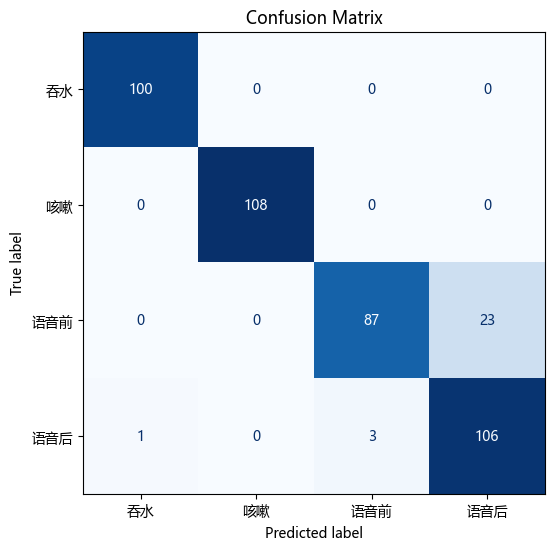

In [5]:
import os
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib


matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

def evaluate_full_accuracy(model, dataset, device, num_classes, batch_size):
    """
    在整个 dataset 上评估模型
    """
    model.eval()
    class_correct = [0] * num_classes
    class_total   = [0] * num_classes
    all_preds, all_labels = [], []

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for features, labels in loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

            for t, p in zip(labels, preds):
                class_total[t] += 1
                if p == t:
                    class_correct[t] += 1

    total_acc = accuracy_score(all_labels, all_preds)
    class_acc = {
        i: (class_correct[i] / class_total[i] if class_total[i] > 0 else 0.0)
        for i in range(num_classes)
    }
    return total_acc, class_acc, all_preds, all_labels


def demo_evaluate_model():
    """
    加载模型，评估并绘制混淆矩阵
    """
    # 实例化网络（结构必须和训练时一致）
    # 这里假设你已经有 num_classes, dropout 与训练相同
    file_paths, labels = load_audio_files(dataset_path)
    le                = LabelEncoder().fit(labels)
    encoded_labels    = le.transform(labels)
    num_classes       = len(le.classes_)
    dataset_for_eval  = MFCCDataset(file_paths, encoded_labels)

    net = ResNetLike(num_classes=num_classes, dropout=0.3).to(device)

    model_path = r"C:\Users\nihao\Desktop\Database\吞咽病患四分类\best_models\epoch054_acc0.9535.pth"
    if not os.path.exists(model_path):
        print(f" 文件不存在: {model_path}")
        return

    # 加载权重
    state = torch.load(model_path, map_location=device)
    net.load_state_dict(state)

    # 评估
    total_acc, class_acc, all_preds, all_labels = evaluate_full_accuracy(
        net, dataset_for_eval, device, num_classes, BATCH_SIZE
    )

    # 打印结果
    print(f"\n模型: {model_path}")
    print(f"整体准确率: {total_acc:.4f}")
    for cls_idx, acc in class_acc.items():
        print(f"  类别 {cls_idx} ({le.classes_[cls_idx]}): {acc:.4f}")

    # 混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    plt.title("Confusion Matrix")
    plt.show()


if __name__ == "__main__":
    demo_evaluate_model()
